In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [5]:
corr_df = df.groupby('left').mean(numeric_only=True)
print(corr_df)

      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  \
left                                                            
0               199.060203            3.380032       0.175009   
1               207.419210            3.876505       0.047326   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


In [7]:
df['left'].value_counts()
corr_df = df.select_dtypes(include='number').corr()[['left']].sort_values(by='left',ascending =False)
print(corr_df)

                           left
left                   1.000000
time_spend_company     0.144822
average_montly_hours   0.071287
number_project         0.023787
last_evaluation        0.006567
promotion_last_5years -0.061788
Work_accident         -0.154622
satisfaction_level    -0.388375


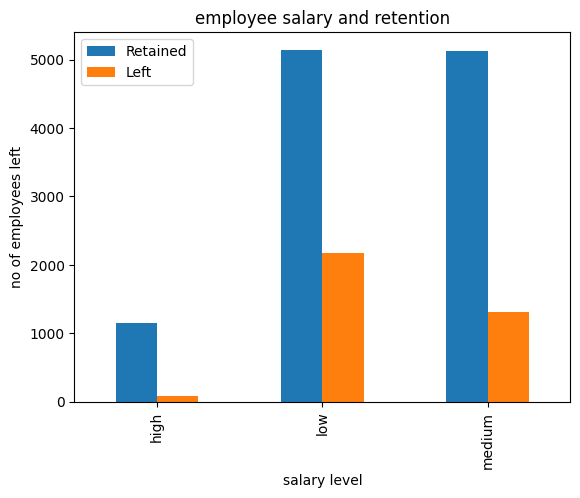

In [9]:
pd.crosstab(df.salary , df.left).plot(kind = 'bar')
plt.title("employee salary and retention")
plt.xlabel("salary level")
plt.ylabel("no of employees left")
plt.legend(['Retained', 'Left'])
plt.show()

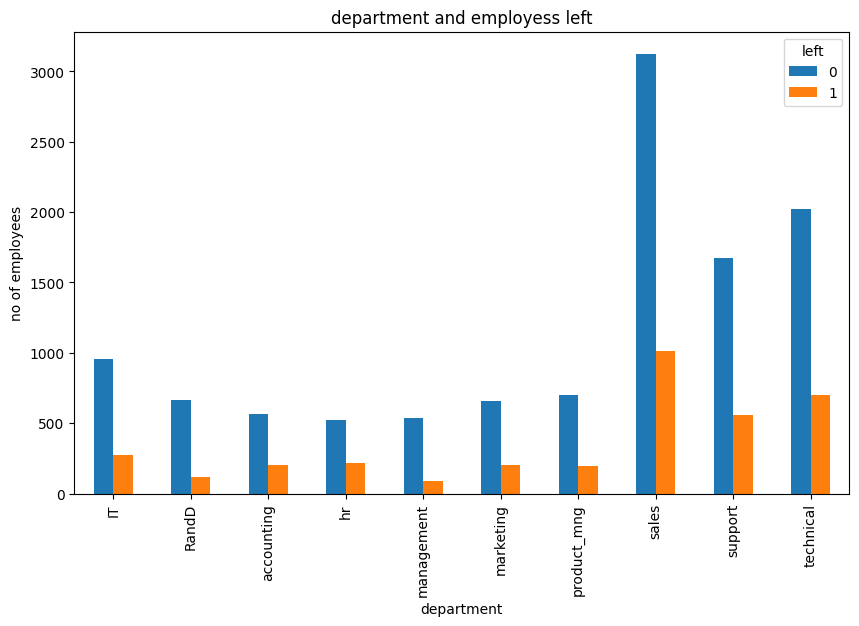

In [11]:
pd.crosstab(df.Department , df.left).plot(kind ='bar' , figsize =(10,6))
plt.title("department and employess left")
plt.xlabel("department")
plt.ylabel("no of employees")
plt.show()


In [12]:
selected_features = df[['satisfaction_level','number_project','average_montly_hours','promotion_last_5years','salary']]

In [13]:
selected_features = pd.get_dummies(selected_features , drop_first = True)
y =df['left']
x = selected_features

In [14]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size =0.2 ,random_state= 42)

In [16]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train , y_train)

LogisticRegression(max_iter=1000)

In [18]:
y_pred = lr.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test , y_pred)
print(cm)

[[2142  152]
 [ 529  177]]


In [20]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test , y_pred)
print(acc)

0.773
